**Experiment C**

In [1]:
# Cell 1 — Install
# Keep Colab's own torch/torchvision pair: install opacus WITHOUT dependencies so pip cannot replace torch.
# (Installing an unpinned torchvision on the current Colab image breaks `import torchvision`.)
!pip -q install --no-deps opacus==1.4.0
import torch, torchvision, opacus
print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| opacus', opacus.__version__, '| cuda', torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 6.4 MB/s eta 0:00:00
torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | opacus 1.4.0 | cuda True


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy

import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt


# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def cleanup_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [3]:
# Cell 3 — Dataset: CIFAR-10 + loaders
# IID CIFAR-10 setup

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616))
])

train_ds = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("dataset: CIFAR-10")
print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 170M/170M [01:43<00:00, 1.65MB/s]


dataset: CIFAR-10
train: 50000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients
# Public points removed from private client datasets.
# IID disjoint client construction for CIFAR-10.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [
        perm[i * samples_per_client:(i + 1) * samples_per_client].tolist()
        for i in range(num_clients)
    ]

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

clients = build_iid_clients_from_indices(
    avail_idx,
    NUM_CLIENTS,
    SAMPLES_PER_CLIENT,
    seed=0
)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 49800
NUM_CLIENTS: 4980 | samples/client: 10 | clients/round: 100
q = 0.020080321285140562


In [5]:
# Cell 4b — OPTIONAL speed-up : cache the datasets as tensors once.
# client_update() builds a new DataLoader per client per round and re-applies ToTensor/Normalize to
# every image on every access; with 100 clients x 180 rounds that CPU work, not the GPU, dominates the
# run time.  Caching applies the same transforms exactly once, so every sample tensor is identical and
# the training numbers are unchanged; runs are typically 1.5-2x faster.  Set to False to disable.
USE_CACHED_TENSORS = True
if USE_CACHED_TENSORS:
    from torch.utils.data import TensorDataset
    class _CachedDS(TensorDataset):
        def __init__(self, ds):
            xs, ys = [], []
            for x, y in DataLoader(ds, batch_size=1024, shuffle=False, num_workers=0):
                xs.append(x); ys.append(y)
            X, Y = torch.cat(xs), torch.cat(ys)
            super().__init__(X, Y)
            self.targets = Y.tolist()
    train_ds = _CachedDS(train_ds)
    test_ds = _CachedDS(test_ds)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)
    print("cached tensors -> train:", tuple(train_ds.tensors[0].shape), "test:", tuple(test_ds.tensors[0].shape))


cached tensors -> train: (50000, 3, 32, 32) test: (10000, 3, 32, 32)


In [6]:
# Cell 4c — Cohort sampling: POISSON 
# Each client participates in a round independently with probability q = CLIENTS_PER_ROUND / N, so the cohort
# has expected size CLIENTS_PER_ROUND and random realized size. This is the sampler the subsampled-Gaussian
# accountant (Poisson subsampling, add/remove adjacency) assumes; fixed-size sampling is not (Lebeda et al., SaTML 2025).
# Denominators that enter a sensitivity bound stay PUBLIC: the private means divide by the expected size
# CLIENTS_PER_ROUND, and AG-PTR caps its noisy count at the public constant COUNT_CAP.
SAMPLING = "poisson"
COUNT_CAP = 2 * CLIENTS_PER_ROUND

def sample_cohort(rng, num_clients, expected):
    if SAMPLING == "poisson":
        chosen = np.flatnonzero(rng.rand(num_clients) < (float(expected) / float(num_clients)))
        if len(chosen) == 0:                       # probability (1-q)^N ~ e^-100; keep the round well defined
            chosen = rng.choice(num_clients, size=1, replace=False)
        return chosen
    return rng.choice(num_clients, size=expected, replace=False)
print("SAMPLING =", SAMPLING, "| expected cohort", CLIENTS_PER_ROUND, "| count cap", COUNT_CAP)


SAMPLING = poisson | expected cohort 100 | count cap 200


In [7]:
# Cell 6 — Model + evaluation
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32x32 -> 16x16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


FMNIST_CNN = CIFAR10_CNN

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [8]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a * b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out

In [9]:
# Cell 8 — Local client update
# Local client update (SGD) returns delta = (local - global)
# LF is interpreted as label flipping with cyclic shift y -> (y + 1) % NUM_CLASSES.

loss_fn = nn.CrossEntropyLoss()

def maybe_flip_labels(y, shift=1):
    return (y + int(shift)) % NUM_CLASSES

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  label_flip=False, label_flip_shift=1):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, client_indices),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if label_flip:
                y = maybe_flip_labels(y, shift=label_flip_shift)

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())

    del local_model
    return delta

In [10]:
# Cell 9 — DP accounting (RDP) + sigma search
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.


from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    try:
        return rdp_analysis.compute_rdp(
            q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders
        )
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(
            orders=orders, rdp=rdp, delta=delta
        )
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)


def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

# ----composed ("certified") accountant for AG-PTR ----
# The two Gaussian phases of one AG-PTR round query the SAME sampled cohort, so the valid
# accounting composes them first into one Gaussian mechanism with effective multiplier
#   sigma_eff = (sigma_sel^-2 + sigma_rel^-2)^-1/2        (= (2/sqrt5)*sigma_rel when sigma_sel = 2*sigma_rel)
# and amplifies THAT mechanism at rate q. This is the only accountant used for AG-PTR.

def sigma_eff_two(sig_sel, sig_rel):
    return float((float(sig_sel) ** -2 + float(sig_rel) ** -2) ** -0.5)

def epsilon_certified_two(sig_sel, sig_rel, q, steps, delta):
    return epsilon_from_sigma_single(sigma_eff_two(sig_sel, sig_rel), q, steps, delta)

def find_sigma_rel_certified_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # smallest sigma_rel whose CERTIFIED epsilon meets the target (sigma_sel = sel_factor*sigma_rel);
    # for eps=2.0 this equals (sqrt(1+sel_factor^2)/sel_factor) * sigma_dp, i.e. 1.0871 on Fashion-MNIST
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_certified_two(sel_factor * sig_rel, sig_rel, q, steps, delta)
    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (certified).")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [11]:
# Cell 10 — Attack helpers
# Byzantine attack helpers for:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Notes:
# - LF is implemented as label flipping and handled inside the train_* functions.
# - SF here is a sign-flip style update attack.
# - FoE here is an inner-product-manipulation / negative-mean style attack.

def normalize_attack_name(name):
    return str(name).strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def is_label_flip_attack(name):
    return normalize_attack_name(name) in {"lf", "labelflip", "labelflipping"}

@torch.no_grad()
def mean_update_list(update_list):
    if len(update_list) == 0:
        raise ValueError("No updates available.")
    P = len(update_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in update_list], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def _pairwise_sq_dists(X):
    gram = X @ X.t()
    diag = torch.diag(gram).unsqueeze(1)
    D = diag + diag.t() - 2.0 * gram
    return D.clamp_min(0.0)

@torch.no_grad()
def _deviation_vec(X):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False)

    dev = sd * torch.sign(mu)
    if torch.norm(dev) < 1e-12:
        dev = mu.clone()
    if torch.norm(dev) < 1e-12:
        dev = torch.ones_like(mu)

    dev = dev / (torch.norm(dev) + 1e-12)
    return mu, dev

def _search_lambda(valid_fn, hi_init=1.0, iters=40):
    lo, hi = 0.0, float(hi_init)

    while valid_fn(hi):
        lo = hi
        hi *= 2.0
        if hi > 1e6:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if valid_fn(mid):
            lo = mid
        else:
            hi = mid

    return float(lo)

@torch.no_grad()
def _attack_vec_alie(X, z=2.0, direction=-1.0):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    return mu + float(direction) * float(z) * sd

@torch.no_grad()
def _attack_vec_sf(X, scale=5.0):
    mu = X.mean(dim=0)
    mean_abs = X.abs().mean(dim=0) + 1e-12
    return -float(scale) * torch.sign(mu) * mean_abs

@torch.no_grad()
def _attack_vec_foe(X, scale=1.0):
    mu = X.mean(dim=0)
    return -float(scale) * mu

@torch.no_grad()
def _attack_vec_minmax(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.max().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def _attack_vec_minsum(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.sum(dim=1).max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.sum().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def build_byzantine_vecs_from_honest(honest_vecs, byz_count,
                                     attack_type="alie",
                                     alie_z=2.0, alie_direction=-1.0,
                                     sf_scale=5.0, foe_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest updates available to build this attack.")

    X = torch.stack(honest_vecs, dim=0)
    attack_key = normalize_attack_name(attack_type)

    if attack_key == "alie":
        mal = _attack_vec_alie(X, z=alie_z, direction=alie_direction)
    elif attack_key == "sf":
        mal = _attack_vec_sf(X, scale=sf_scale)
    elif attack_key == "minmax":
        mal = _attack_vec_minmax(X)
    elif attack_key == "minsum":
        mal = _attack_vec_minsum(X)
    elif attack_key in {"foe", "ipm", "fallofempires"}:
        mal = _attack_vec_foe(X, scale=foe_scale)
    elif is_label_flip_attack(attack_key):
        raise ValueError("LF is handled inside the training functions, not from honest updates.")
    else:
        raise ValueError(f"Unknown attack_type={attack_type!r}")

    mal = mal.detach()
    return [mal.clone() for _ in range(byz_count)]

@torch.no_grad()
def build_byzantine_updates_from_honest(honest_updates, byz_count,
                                        attack_type="alie",
                                        alie_z=2.0, alie_direction=-1.0,
                                        sf_scale=5.0, foe_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates available to build this attack.")

    template = honest_updates[0]
    honest_vecs = [flatten_list(u) for u in honest_updates]
    mal_vecs = build_byzantine_vecs_from_honest(
        honest_vecs, byz_count,
        attack_type=attack_type,
        alie_z=alie_z, alie_direction=alie_direction,
        sf_scale=sf_scale, foe_scale=foe_scale
    )

    out = []
    for v in mal_vecs:
        out.append([t.detach().clone() for t in unflatten_like(v, template)])
    return out

In [12]:
# Cell 11 — DP-FedAvg with selectable attacks
def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           attack_type="alie",
                           alie_direction=-1.0, alie_z=2.0,
                           sf_scale=5.0, foe_scale=1.0,
                           label_flip_shift=1,
                           show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"DP-FedAvg {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_client_ids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [13]:
# Cell 12 — AG-PTR with selectable attacks


def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(pub_batch_size, len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())

    del local_model
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD step (public_epochs)
      - anchor = pub_scale * delta_pub
    """
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 attack_type="alie",
                 alie_direction=-1.0, alie_z=2.0,
                 sf_scale=5.0, foe_scale=1.0,
                 label_flip_shift=1,
                 allow_zero=False,
                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)
    accept = 0

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"AG-PTR {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        byz_client_ids, byz_slots = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        # ---- rebuild full deltas ----
        deltas = [None] * len(chosen)
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0)
                n_pub += 1
            else:
                assign.append(1)

        n_zero = len(chosen) - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(COUNT_CAP), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        # Normalize first, then add release noise in mean space
        mean_offsets = [so / m_hat for so in sum_offsets]

        noise_std = (float(sigma_rel) * float(rho)) / float(m_hat)
        for j in range(len(mean_offsets)):
            mean_offsets[j].add_(torch.randn_like(mean_offsets[j]) * noise_std)

        mean_update = [a + mo for a, mo in zip(a_star, mean_offsets)]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    accept_rate = accept / rounds
    del model
    cleanup_cuda()
    return acc, accept_rate

In [14]:
# Cell 13 — FedVRDP with selectable attacks
@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)
    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * len(chosen)
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        mask = topk_mask_from_vec(avg_vec.detach(), k)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [15]:
# Cell 13.1 — Robust baseline helpers
# Helpers used by Median / Trimmed Mean / Krum / SparseFed-style baselines.

def build_round_updates(model, rng, byz_frac, lr_t, momentum,
                        local_epochs=1, batch_size=10,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1):
    """
    Build the full list of client updates for one round, including honest and Byzantine clients.
    Returns:
        updates: list length CLIENTS_PER_ROUND, each entry is a list-of-tensors update
        byz_count: integer number of Byzantine clients in this round
    """
    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    chosen = sample_cohort(rng, num_clients, clients_per_round)

    b = int(round(byz_frac * len(chosen)))
    byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

    honest_updates, honest_slots = [], []
    byz_client_ids, byz_slots = [], []

    attack_key = normalize_attack_name(attack_type)

    for j, cid in enumerate(chosen):
        if j in byz_pos:
            byz_client_ids.append(cid)
            byz_slots.append(j)
            continue

        honest_updates.append(
            client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
        )
        honest_slots.append(j)

    if b > 0:
        if is_label_flip_attack(attack_key):
            byz_updates = [
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size,
                    label_flip=True, label_flip_shift=label_flip_shift
                )
                for cid in byz_client_ids
            ]
        else:
            byz_updates = build_byzantine_updates_from_honest(
                honest_updates, b,
                attack_type=attack_key,
                alie_z=alie_z, alie_direction=alie_direction,
                sf_scale=sf_scale, foe_scale=foe_scale
            )
    else:
        byz_updates = []

    updates = [None] * len(chosen)
    for upd, j in zip(honest_updates, honest_slots):
        updates[j] = upd
    for upd, j in zip(byz_updates, byz_slots):
        updates[j] = upd

    return updates, b


@torch.no_grad()
def stack_updates_cpu(update_list):
    """
    Convert a list of list-of-tensors updates into an [n_clients, d] CPU tensor.
    """
    return torch.stack(
        [flatten_list(upd).detach().cpu() for upd in update_list],
        dim=0
    )


@torch.no_grad()
def clip_flat_vec(vec, clip_C):
    nrm = torch.norm(vec) + 1e-12
    return vec * min(1.0, float(clip_C) / float(nrm))


@torch.no_grad()
def apply_flat_update_(model, flat_vec_cpu):
    """
    Apply a flattened update vector (stored on CPU) to the model.
    """
    template = zero_like_params(model)
    upd_list = unflatten_like(flat_vec_cpu.to(device), template)
    add_update_(model, upd_list, scale=1.0)


@torch.no_grad()
def coord_median_vec(mat):
    """
    Coordinate-wise median over rows of mat, shape [n, d].
    """
    return mat.median(dim=0).values


@torch.no_grad()
def trimmed_mean_vec(mat, trim_k):
    """
    Coordinate-wise trimmed mean over rows of mat, trimming trim_k smallest
    and trim_k largest values in each coordinate.
    """
    n = mat.size(0)
    trim_k = int(max(0, min(int(trim_k), (n - 1) // 2)))

    if trim_k == 0 or 2 * trim_k >= n:
        return mat.mean(dim=0)

    vals, _ = torch.sort(mat, dim=0)
    return vals[trim_k:n - trim_k].mean(dim=0)


@torch.no_grad()
def krum_select_vec(mat, byz_count):
    """
    Krum selection rule on flattened client updates.
    Score(i) = sum of squared distances to the n - f - 2 nearest neighbors.
    Returns the selected update vector.
    """
    n = mat.size(0)
    neighbor_count = max(1, min(n - 1, n - int(byz_count) - 2))

    sq = _pairwise_sq_dists(mat)

    scores = []
    for i in range(n):
        d = torch.cat([sq[i, :i], sq[i, i + 1:]])
        vals, _ = torch.topk(d, k=neighbor_count, largest=False)
        scores.append(vals.sum())

    scores = torch.stack(scores)
    idx = int(torch.argmin(scores).item())
    return mat[idx].clone()


@torch.no_grad()
def topk_sparsify_vec(vec, k):
    """
    Keep only the top-k coordinates (by magnitude).
    """
    d = vec.numel()
    k = min(int(k), d)

    out = torch.zeros_like(vec)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        out[idx] = vec[idx]
    return out

In [16]:
# Cell 13.2 — Median baseline
# Non-private coordinate-wise median aggregator.

def train_median_robust(seed, eps_total, byz_frac,
                        delta=1e-5,
                        rounds=30, local_epochs=10, batch_size=10,
                        lr0=0.125, lr_decay=0.99, momentum=0.5,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1,
                        show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Median {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = coord_median_vec(mat)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [17]:
# Cell 13.3 — Trimmed Mean baseline
# Non-private coordinate-wise trimmed mean aggregator.

def train_trimmedmean_robust(seed, eps_total, byz_frac,
                             delta=1e-5,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             trim_k=None,   # if None, use the actual byzantine count b each round
                             attack_type="alie",
                             alie_direction=-1.0, alie_z=2.0,
                             sf_scale=5.0, foe_scale=1.0,
                             label_flip_shift=1,
                             show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"TrimmedMean {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        trim_this_round = b if trim_k is None else int(trim_k)
        agg_vec = trimmed_mean_vec(mat, trim_this_round)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [18]:
# Cell 13.4 — Krum baseline
# Non-private Krum aggregator.
# Note: Krum's formal guarantee requires n > 2f + 2, but the score is still computable
# for all f values used in this smoke test.

def train_krum_robust(seed, eps_total, byz_frac,
                      delta=1e-5,
                      rounds=30, local_epochs=10, batch_size=10,
                      lr0=0.125, lr_decay=0.99, momentum=0.5,
                      attack_type="alie",
                      alie_direction=-1.0, alie_z=2.0,
                      sf_scale=5.0, foe_scale=1.0,
                      label_flip_shift=1,
                      show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Krum {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = krum_select_vec(mat, b)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [19]:
# Cell 13.5 — SparseFed-style baseline
# Non-private simplified SparseFed-style baseline:
#   1) device-level clipping on client updates
#   2) average
#   3) global top-k sparsification of the averaged update

def train_sparsefed_style_robust(seed, eps_total, byz_frac,
                                 delta=1e-5,
                                 rounds=30, local_epochs=10, batch_size=10,
                                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                                 clip_C=1.0, k_frac=0.30,
                                 attack_type="alie",
                                 alie_direction=-1.0, alie_z=2.0,
                                 sf_scale=5.0, foe_scale=1.0,
                                 label_flip_shift=1,
                                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    iterator = tqdm(
        range(rounds),
        desc=f"SparseFed-style {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)

        clipped_rows = []
        for i in range(mat.size(0)):
            clipped_rows.append(clip_flat_vec(mat[i], clip_C))
        clipped_mat = torch.stack(clipped_rows, dim=0)

        avg_vec = clipped_mat.mean(dim=0)
        sparse_vec = topk_sparsify_vec(avg_vec, k)

        apply_flat_update_(model, sparse_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [20]:
# Cell 13.7 — FedVRDP (faithful to Zhang & Hu, IEEE CNS 2023, Algorithm 1): local momentum SGD with the momentum
# buffer re-initialized every round (client_update creates a fresh optimizer), per-client sparsification with a binary
# mask, clipping at C, Gaussian noise on the k kept coordinates (added on the securely aggregated sum, multiplier
# sigma_dp so the budget is the certified eps = 2), plain averaging over the expected cohort size; the mask starts at k
# random coordinates and is refreshed every round as the top-k coordinates of the global model. Their Fashion-MNIST
# setting: p = k/d = 0.3, C = 0.5, momentum 0.5, lr 0.125 * 0.99^t, batch 10, T = 180 (local epochs: 10 in the paper;
# the common protocol here uses 1, and a 10-epoch variant is run on Experiment A).
def train_fedvrdp_faithful(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    # Zhang & Hu (2023), Algorithm 1, line 2: initial mask = k coordinates chosen uniformly at random
    mask = torch.zeros(d, device=device)
    mask[torch.from_numpy(rng.choice(d, size=k, replace=False)).to(device)] = 1.0
    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = sample_cohort(rng, num_clients, clients_per_round)

        b = int(round(byz_frac * len(chosen)))
        byz_pos = set(rng.choice(len(chosen), size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * len(chosen)
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        # Algorithm 1, line 9: m^{t+1} <- TopMask(x^{t+1}, k): the k largest-magnitude coordinates of the updated
        # GLOBAL MODEL (a post-processing of released outputs, so DP-safe; coordinates can re-enter the support)
        mask = topk_mask_from_vec(flatten_list(model_param_list(model)).detach().abs(), k)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0


In [22]:
# Cell 16 — Driver DEFINITIONS (certified budget only). Run once per session; runs nothing by itself.
#  * Every AG-PTR run uses the composed accountant (Lemma "joint release"): sigma_rel is the smallest multiplier
#    whose certified epsilon is exactly the target (1.0871 on Fashion-MNIST, 1.1558 on CIFAR-10, sigma_sel = 2 sigma_rel).
#    Baselines use the single-release multiplier sigma_dp for the same target. 
import os, time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRESETS = {
    "smoke": dict(RUN_TAG="smokeC", SEEDS=[0], SUBSET_ATTACKS=["alie"], SUBSET_FRACS=[0.0], SUBSET_METHODS=["AG-PTR", "DP-FedAvg"], ROUNDS=3, MAX_RUNS_THIS_SESSION=2),
    "grid":  dict(RUN_TAG="pC", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["DP-FedAvg", "FedVRDP-style", "Median", "TrimmedMean", "Krum", "SparseFed-style", "AG-PTR"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "fedvrdp": dict(RUN_TAG="pC", SEEDS=[0], SUBSET_ATTACKS=["alie", "sf", "minmax", "minsum", "lf", "foe"], SUBSET_FRACS=None, SUBSET_METHODS=["FedVRDP"], ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
    "custom": dict(RUN_TAG="pC", SEEDS=[0], SUBSET_ATTACKS=None, SUBSET_FRACS=None, SUBSET_METHODS=None, ROUNDS=180, MAX_RUNS_THIS_SESSION=None),
}
RESULTS_DIR = "/content/drive/MyDrive/agptr_runs"

try:
    from google.colab import drive as _gdrive
    if not os.path.isdir("/content/drive/MyDrive"):
        _gdrive.mount("/content/drive")
except Exception as _e:
    raise RuntimeError("Google Drive is NOT mounted (%s). Results would be lost when the session ends. "
                       "Run:  from google.colab import drive; drive.mount('/content/drive')  , authorize, then re-run this cell." % (_e,))
if not os.path.isdir("/content/drive/MyDrive"):
    raise RuntimeError("Google Drive is NOT mounted: /content/drive/MyDrive does not exist. Mount it and re-run this cell.")
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- fixed experiment settings (identical to the paper's full-run cell) ----
eps_total = 2.0
delta = 1e-5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10
LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1
RHO = 0.4
TAU = 50
R_PUB_AVG = 16
PUB_BATCH = 40
PUB_SCALE = 0.12
PUBLIC_EPOCHS = 2
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30
RHO = 0.3
TAU = 35
PUB_BATCH = 80
PUB_SCALE = 0.002

ATTACKS_ALL = [("ALIE","alie"), ("SF","sf"), ("MinMax","minmax"), ("MinSum","minsum"), ("LF","lf"), ("FoE","foe")]
METHODS_ALL = ["DP-FedAvg", "FedVRDP-style", "Median", "TrimmedMean", "Krum", "SparseFed-style", "AG-PTR", "FedVRDP"]
AGPTR_METHODS = ["AG-PTR"]      # rows of these methods depend on sigma_rel; all others do not
FRACS_ALL = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]
q = CLIENTS_PER_ROUND / len(clients)
sigma_dp = find_sigma_for_target_eps_single(eps_total, q, 180, delta)     # baselines: one release per round, T = 180
MODE = "certified"
PRIVATE_METHODS = {"DP-FedAvg", "FedVRDP-style", "FedVRDP", "AG-PTR"}
assert SAMPLING == "poisson", "this driver certifies Poisson sampling only"

def _key(attack_key, method, f, seed):
    return (str(attack_key), str(method), "%.2f" % float(f), int(seed))

def load_done(csv_path):
    if not os.path.exists(csv_path):
        return set()
    df = pd.read_csv(csv_path)
    if "status" in df.columns:
        df = df[df["status"] == "ok"]
    return set(_key(r.attack_key, r.method, r.f, r.seed) for r in df.itertuples())

def append_row(csv_path, row):
    header = not os.path.exists(csv_path)
    pd.DataFrame([row]).to_csv(csv_path, mode="a", header=header, index=False)
    try:
        with open(csv_path, "a") as fh:
            fh.flush(); os.fsync(fh.fileno())
    except Exception:
        pass

def _sigmas(rounds):
    sr = find_sigma_rel_certified_two(eps_total, q, rounds, delta, sel_factor=2.0)
    ss = 2.0 * sr
    return ss, sr, epsilon_certified_two(ss, sr, q, rounds, delta)

CFG = {}   # filled by run_job(); read by run_method()

# ---- method dispatch (same arguments as the original full-run cell) ----
def run_method(method, seed, f, attack_key):
    common = dict(delta=delta, rounds=CFG["ROUNDS"], local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                  lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM, attack_type=attack_key,
                  alie_direction=ALIE_DIR, alie_z=ALIE_Z, sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
                  label_flip_shift=LABEL_FLIP_SHIFT, show_progress=False)
    if method == "DP-FedAvg":
        return train_dp_fedavg_robust(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_DP, **common)
    if method == "FedVRDP-style":
        return train_fedvrdp_robust(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **common)
    if method == "Median":
        return train_median_robust(seed, eps_total, f, **common)
    if method == "TrimmedMean":
        return train_trimmedmean_robust(seed, eps_total, f, trim_k=None, **common)
    if method == "Krum":
        return train_krum_robust(seed, eps_total, f, **common)
    if method == "SparseFed-style":
        return train_sparsefed_style_robust(seed, eps_total, f, clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE, **common)
    if method == "AG-PTR":
        return train_ag_ptr(seed, eps_total, f, CFG["sigma_sel"], CFG["sigma_rel"], rho=RHO, tau=TAU,
                            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                            allow_zero=False, **common)
    if method == "FedVRDP":
        return train_fedvrdp_faithful(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **common)
    if method == "FedVRDP-10ep":
        c10 = dict(common); c10["local_epochs"] = 10
        return train_fedvrdp_faithful(seed, eps_total, f, sigma_dp, clip_C=CLIP_C_VR, k_frac=K_FRAC_VR, **c10)
    raise ValueError("unknown method %s" % method)

def run_job(job):
    P = PRESETS[job]
    rounds = P["ROUNDS"]
    ss, sr, eps_cert = _sigmas(rounds)
    CFG.update(dict(RUN_TAG=P["RUN_TAG"], ROUNDS=rounds, sigma_sel=ss, sigma_rel=sr))
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    print("JOB = %s | results file: %s" % (job, csv_path))
    print("q = %.6f | sigma_dp = %.4f | AG-PTR: sigma_sel = %.4f, sigma_rel = %.4f | certified epsilon = %.3f" % (q, sigma_dp, ss, sr, eps_cert))
    attacks = [(n, k) for (n, k) in ATTACKS_ALL if (P["SUBSET_ATTACKS"] is None or k in P["SUBSET_ATTACKS"])]
    fracs   = FRACS_ALL if P["SUBSET_FRACS"] is None else list(P["SUBSET_FRACS"])
    methods = METHODS_ALL if P["SUBSET_METHODS"] is None else list(P["SUBSET_METHODS"])
    unknown = [m for m in methods if m not in METHODS_ALL]
    if unknown:
        raise ValueError("Unknown method(s): %s" % unknown)
    done = load_done(csv_path)
    todo = [(seed, a_name, a_key, f, m) for seed in P["SEEDS"] for (a_name, a_key) in attacks for f in fracs for m in methods
            if not (a_key == "inball" and m != "AG-PTR") and _key(a_key, m, f, seed) not in done]
    print("%d runs already done, %d to do" % (len(done), len(todo)))
    n_done_now, t_start = 0, time.time()
    for (seed, a_name, a_key, f, m) in todo:
        t0 = time.time(); status, err = "ok", ""
        try:
            acc, ar = run_method(m, seed, f, a_key)
        except Exception as e:
            acc, ar, status, err = np.nan, np.nan, "error", repr(e)[:300]
        append_row(csv_path, {"exp": P["RUN_TAG"], "attack": a_name, "attack_key": a_key, "method": m, "f": float(f), "seed": int(seed),
                              "sigma_mode": MODE, "sigma_dp": sigma_dp, "sigma_sel": (ss if m in AGPTR_METHODS else np.nan),
                              "sigma_rel": (sr if m in AGPTR_METHODS else np.nan), "eps_certified": (eps_cert if m in AGPTR_METHODS else (eps_total if m in PRIVATE_METHODS else np.nan)), "is_private": (m in PRIVATE_METHODS), "sampling": SAMPLING,
                              "rounds": rounds, "acc": acc, "accept_rate": ar, "wall_sec": round(time.time() - t0, 1),
                              "status": status, "error": err, "source": "run",
                              "timestamp": datetime.datetime.now().isoformat(timespec="seconds")})
        n_done_now += 1
        try:
            cleanup_cuda()
        except Exception:
            pass
        eta = (time.time() - t_start) / n_done_now * (len(todo) - n_done_now)
        print("[%d/%d] seed=%d %-7s f=%.2f %-24s acc=%s accept=%s (%s, %.0fs, ETA %.0f min)"
              % (n_done_now, len(todo), seed, a_name, f, m, "n/a" if acc != acc else "%.4f" % acc,
                 "n/a" if ar != ar else "%.3f" % ar, status, time.time() - t0, eta / 60))
    print("done for now:", csv_path)
    return csv_path

def import_legacy(job, legacy_name=""):
    if not legacy_name:
        print("no legacy import under Poisson sampling: every reported row is a new run"); return
    # adds the paper's original seed-0 BASELINE rows (they do not depend on sigma_rel) to the job's CSV;
    # AG-PTR rows are NOT imported: every reported AG-PTR number comes from the certified runs.
    P = PRESETS[job]
    if job == "smoke":
        print("smoke job: legacy import skipped"); return
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    cands = [os.path.join(RESULTS_DIR, legacy_name), legacy_name, os.path.join("/content", legacy_name)]
    src = next((p for p in cands if os.path.exists(p)), None)
    if src is None:
        print("legacy file", legacy_name, "not found - skipped"); return
    leg = pd.read_csv(src); name2key = {n: k for (n, k) in ATTACKS_ALL}; done = load_done(csv_path); added = 0
    for r in leg.itertuples():
        if str(r.method) in AGPTR_METHODS:
            continue
        a_key = name2key.get(str(r.attack), str(r.attack).lower())
        if _key(a_key, r.method, r.f, 0) in done:
            continue
        append_row(csv_path, {"exp": P["RUN_TAG"], "attack": r.attack, "attack_key": a_key, "method": r.method, "f": float(r.f), "seed": 0,
                              "sigma_mode": MODE, "sigma_dp": np.nan, "sigma_sel": np.nan, "sigma_rel": np.nan, "eps_certified": eps_total,
                              "rounds": 180, "acc": r.acc, "accept_rate": r.accept_rate, "wall_sec": np.nan, "status": "ok", "error": "",
                              "source": "legacy", "timestamp": datetime.datetime.now().isoformat(timespec="seconds")})
        added += 1
    print("imported %d legacy baseline rows (seed 0) from %s" % (added, src))

def print_job_log(job):
    # FULL LOG: every completed run of this job, from all sessions, read back from the CSV (with timestamps).
    P = PRESETS[job]
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    if not os.path.exists(csv_path):
        print("no results file yet for", job); return
    df = pd.read_csv(csv_path)
    attacks = [k for (n, k) in ATTACKS_ALL if (P["SUBSET_ATTACKS"] is None or k in P["SUBSET_ATTACKS"])]
    methods = METHODS_ALL if P["SUBSET_METHODS"] is None else list(P["SUBSET_METHODS"])
    fracs = [round(float(x), 2) for x in (FRACS_ALL if P["SUBSET_FRACS"] is None else P["SUBSET_FRACS"])]
    sel = df[(df["source"] == "run") & df["attack_key"].isin(attacks) & df["method"].isin(methods) & df["seed"].isin(P["SEEDS"]) & df["f"].round(2).isin(fracs)]
    sel = sel.sort_values("timestamp").reset_index(drop=True)
    print("FULL LOG for job '%s': %d completed runs over all sessions (%d ok, %d error) - file %s"
          % (job, len(sel), int((sel["status"] == "ok").sum()), int((sel["status"] != "ok").sum()), csv_path))
    cols = ["timestamp", "seed", "attack", "f", "method", "acc", "accept_rate", "wall_sec", "status", "sigma_rel", "eps_certified"]
    with pd.option_context("display.max_rows", 1000, "display.width", 220):
        display(sel[cols])

def aggregate(job):
    # mean +/- std over seeds per (attack, method, f), summary CSV, error-bar plots
    P = PRESETS[job]
    csv_path = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_results.csv")
    df = pd.read_csv(csv_path); df = df[df["status"] == "ok"].copy()
    summary = (df.groupby(["attack_key", "attack", "method", "f"])
                 .agg(acc_mean=("acc", "mean"), acc_std=("acc", "std"), n_seeds=("acc", "count"),
                      accept_mean=("accept_rate", "mean"), accept_std=("accept_rate", "std"))
                 .reset_index().sort_values(["attack_key", "method", "f"]))
    summary["acc_std"] = summary["acc_std"].fillna(0.0)
    out = os.path.join(RESULTS_DIR, P["RUN_TAG"] + "_seed_summary.csv"); summary.to_csv(out, index=False)
    print("saved", out); display(summary)
    for a_key, sub in summary.groupby("attack_key"):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for m, ss_ in sub.groupby("method"):
            ss_ = ss_.sort_values("f")
            ax.errorbar(ss_["f"], ss_["acc_mean"], yerr=ss_["acc_std"], marker="o", capsize=3, label="%s (n=%d)" % (m, int(ss_["n_seeds"].max())))
        ax.set_xlabel("Byzantine fraction"); ax.set_ylabel("Test accuracy (mean +/- std over seeds)")
        ax.set_title("%s - %s - certified epsilon = 2.0" % (P["RUN_TAG"], a_key.upper())); ax.grid(True, alpha=0.3); ax.legend(loc="best", fontsize=7, ncol=2)
        fig.tight_layout(); plt.show()
print("driver definitions loaded (certified budget only); now run the job cells below")


Mounted at /content/drive
driver definitions loaded (certified budget only); now run the job cells below


JOB = smoke | results file: /content/drive/MyDrive/agptr_runs/smokeC_results.csv
q = 0.020080 | sigma_dp = 1.0338 | AG-PTR: sigma_sel = 1.8176, sigma_rel = 0.9088 | certified epsilon = 2.000
0 runs already done, 2 to do
[1/2] seed=0 ALIE    f=0.00 AG-PTR                   acc=0.1598 accept=1.000 (ok, 3s, ETA 0 min)
[2/2] seed=0 ALIE    f=0.00 DP-FedAvg                acc=0.1309 accept=1.000 (ok, 1s, ETA 0 min)
done for now: /content/drive/MyDrive/agptr_runs/smokeC_results.csv
no legacy import under Poisson sampling: every reported row is a new run
FULL LOG for job 'smoke': 2 completed runs over all sessions (2 ok, 0 error) - file /content/drive/MyDrive/agptr_runs/smokeC_results.csv


,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-09T00:32:34,0,ALIE,0.0,AG-PTR,0.1598,1.0,3.3,ok,0.908805,2.0
1,2026-09-09T00:32:36,0,ALIE,0.0,DP-FedAvg,0.1309,1.0,1.4,ok,NaN,2.0


saved /content/drive/MyDrive/agptr_runs/smokeC_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.0,0.1598,0.0,1,1.0,NaN
1,alie,ALIE,DP-FedAvg,0.0,0.1309,0.0,1,1.0,NaN


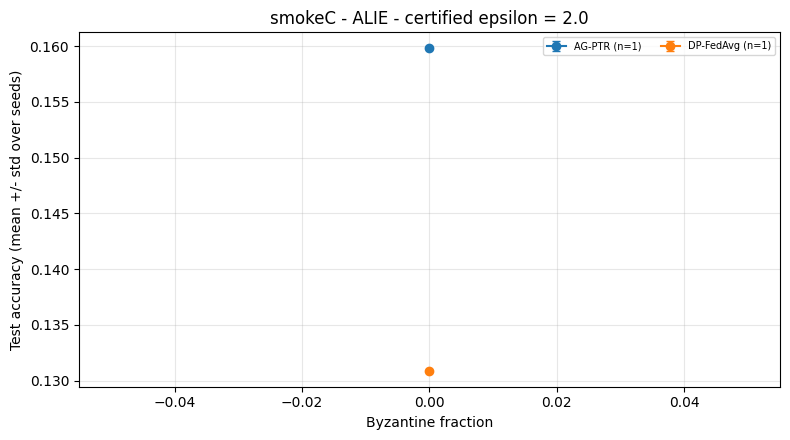

In [ ]:
# Cell 16a — JOB: smoke  (2 short runs)
run_job("smoke")          # runs only what is missing; safe to re-run
import_legacy("smoke")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("smoke")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("smoke")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = grid | results file: /content/drive/MyDrive/agptr_runs/pC_results.csv
q = 0.020080 | sigma_dp = 1.0338 | AG-PTR: sigma_sel = 2.3117, sigma_rel = 1.1558 | certified epsilon = 2.000
0 runs already done, 294 to do
[1/294] seed=0 ALIE    f=0.00 DP-FedAvg                acc=0.2824 accept=1.000 (ok, 69s, ETA 336 min)
[2/294] seed=0 ALIE    f=0.00 FedVRDP-style            acc=0.3350 accept=1.000 (ok, 67s, ETA 329 min)
[3/294] seed=0 ALIE    f=0.00 Median                   acc=0.4423 accept=1.000 (ok, 180s, ETA 510 min)
[4/294] seed=0 ALIE    f=0.00 TrimmedMean              acc=0.4795 accept=1.000 (ok, 102s, ETA 505 min)
[5/294] seed=0 ALIE    f=0.00 Krum                     acc=0.3497 accept=1.000 (ok, 111s, ETA 509 min)
[6/294] seed=0 ALIE    f=0.00 SparseFed-style          acc=0.4678 accept=1.000 (ok, 111s, ETA 512 min)
[7/294] seed=0 ALIE    f=0.00 AG-PTR                   acc=0.3873 accept=0.850 (ok, 102s, ETA 507 min)
[8/294] seed=0 ALIE    f=0.10 DP-FedAvg                acc=0.157

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-09T00:33:47,0,ALIE,0.00,DP-FedAvg,0.2824,1.000000,68.7,ok,NaN,2.0
1,2026-09-09T00:34:54,0,ALIE,0.00,FedVRDP-style,0.3350,1.000000,66.5,ok,NaN,2.0
2,2026-09-09T00:37:54,0,ALIE,0.00,Median,0.4423,1.000000,179.8,ok,NaN,NaN
3,2026-09-09T00:39:36,0,ALIE,0.00,TrimmedMean,0.4795,1.000000,102.4,ok,NaN,NaN
4,2026-09-09T00:41:27,0,ALIE,0.00,Krum,0.3497,1.000000,110.7,ok,NaN,NaN
5,2026-09-09T00:43:18,0,ALIE,0.00,SparseFed-style,0.4678,1.000000,111.4,ok,NaN,NaN
6,2026-09-09T00:45:00,0,ALIE,0.00,AG-PTR,0.3873,0.850000,102.3,ok,1.155826,2.0
7,2026-09-09T00:46:05,0,ALIE,0.10,DP-FedAvg,0.1573,1.000000,64.6,ok,NaN,2.0
8,2026-09-09T00:47:08,0,ALIE,0.10,FedVRDP-style,0.2120,1.000000,62.8,ok,NaN,2.0
9,2026-09-09T00:50:02,0,ALIE,0.10,Median,0.3652,1.000000,174.5,ok,NaN,NaN


saved /content/drive/MyDrive/agptr_runs/pC_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,AG-PTR,0.00,0.3873,0.0,1,0.850000,NaN
1,alie,ALIE,AG-PTR,0.10,0.3588,0.0,1,0.950000,NaN
2,alie,ALIE,AG-PTR,0.20,0.3329,0.0,1,0.711111,NaN
3,alie,ALIE,AG-PTR,0.30,0.3017,0.0,1,0.411111,NaN
4,alie,ALIE,AG-PTR,0.40,0.2696,0.0,1,0.205556,NaN
...,...,...,...,...,...,...,...,...,...
289,sf,SF,TrimmedMean,0.20,0.1688,0.0,1,1.000000,NaN
290,sf,SF,TrimmedMean,0.30,0.1574,0.0,1,1.000000,NaN
291,sf,SF,TrimmedMean,0.40,0.1564,0.0,1,1.000000,NaN
292,sf,SF,TrimmedMean,0.49,0.1539,0.0,1,1.000000,NaN


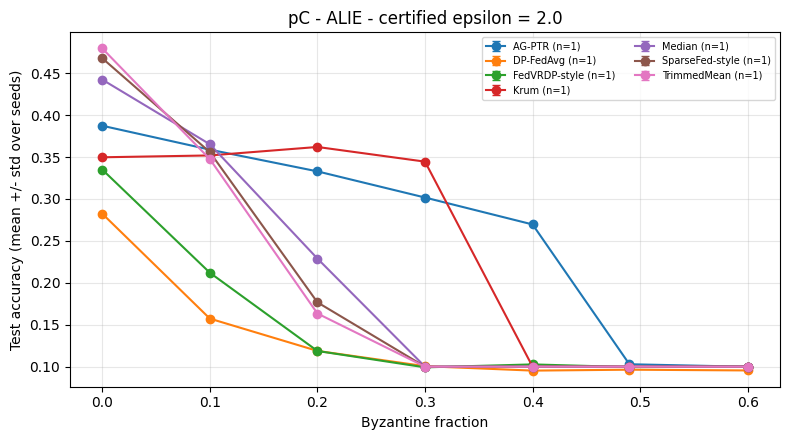

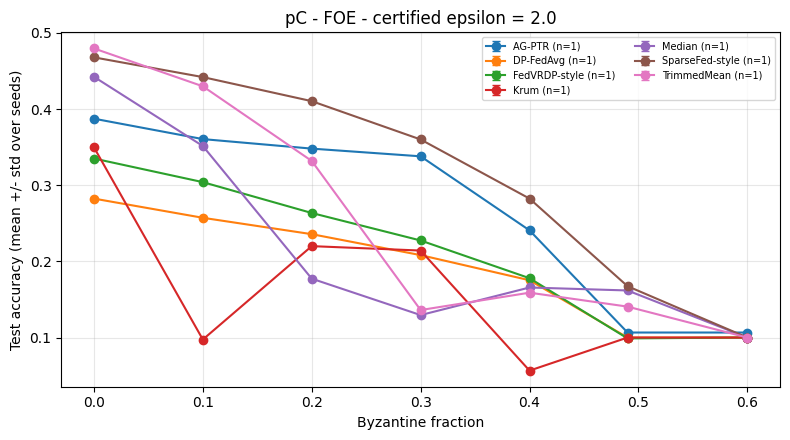

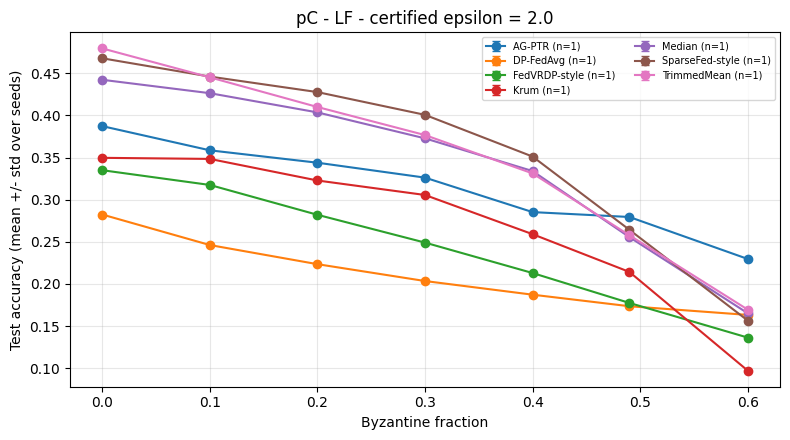

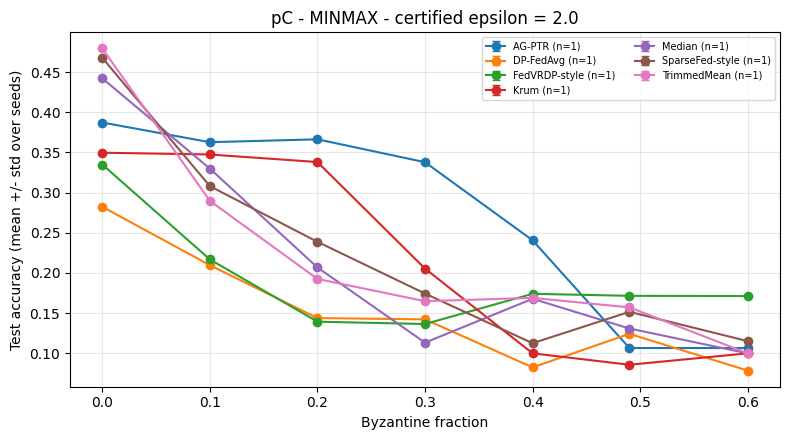

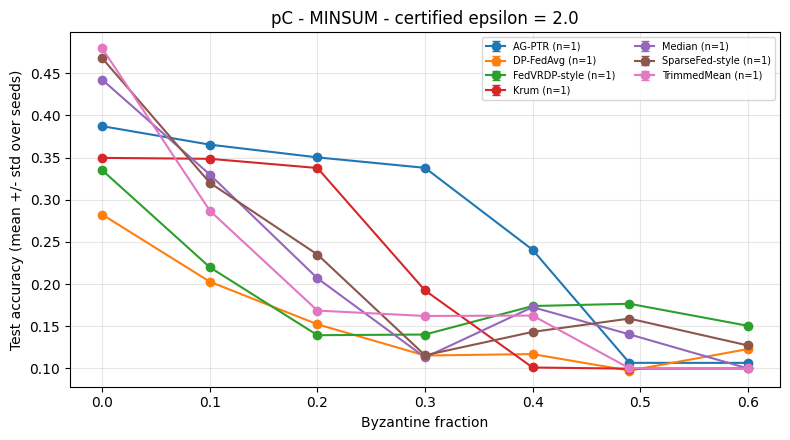

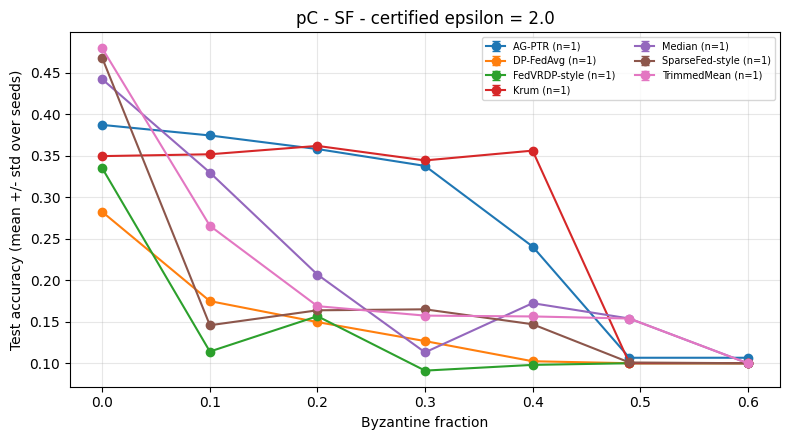

In [ ]:
# Cell 16b — JOB: grid  (294 runs: all seven methods, six attacks, seven fractions)
run_job("grid")          # runs only what is missing; safe to re-run
import_legacy("grid")    # adds the paper's seed-0 rows to the CSV (once)
print_job_log("grid")    # FULL LOG of every run of this job, all sessions, with timestamps
aggregate("grid")        # mean +/- std over seeds, summary CSV, error-bar plots


JOB = fedvrdp | results file: /content/drive/MyDrive/agptr_runs/pC_results.csv
q = 0.020080 | sigma_dp = 1.0338 | AG-PTR: sigma_sel = 2.3117, sigma_rel = 1.1558 | certified epsilon = 2.000
0 runs already done, 42 to do
[1/42] seed=0 ALIE    f=0.00 FedVRDP                  acc=0.3741 accept=1.000 (ok, 70s, ETA 48 min)
[2/42] seed=0 ALIE    f=0.10 FedVRDP                  acc=0.2562 accept=1.000 (ok, 62s, ETA 44 min)
[3/42] seed=0 ALIE    f=0.20 FedVRDP                  acc=0.0976 accept=1.000 (ok, 55s, ETA 40 min)
[4/42] seed=0 ALIE    f=0.30 FedVRDP                  acc=0.1044 accept=1.000 (ok, 49s, ETA 37 min)
[5/42] seed=0 ALIE    f=0.40 FedVRDP                  acc=0.1103 accept=1.000 (ok, 42s, ETA 34 min)
[6/42] seed=0 ALIE    f=0.49 FedVRDP                  acc=0.0999 accept=1.000 (ok, 36s, ETA 31 min)
[7/42] seed=0 ALIE    f=0.60 FedVRDP                  acc=0.1000 accept=1.000 (ok, 30s, ETA 29 min)
[8/42] seed=0 SF      f=0.00 FedVRDP                  acc=0.3741 accept=1.000 (ok

,timestamp,seed,attack,f,method,acc,accept_rate,wall_sec,status,sigma_rel,eps_certified
0,2026-09-10T12:02:15,0,ALIE,0.00,FedVRDP,0.3741,1.0,69.8,ok,NaN,2.0
1,2026-09-10T12:03:17,0,ALIE,0.10,FedVRDP,0.2562,1.0,61.9,ok,NaN,2.0
2,2026-09-10T12:04:12,0,ALIE,0.20,FedVRDP,0.0976,1.0,54.8,ok,NaN,2.0
3,2026-09-10T12:05:01,0,ALIE,0.30,FedVRDP,0.1044,1.0,49.1,ok,NaN,2.0
4,2026-09-10T12:05:44,0,ALIE,0.40,FedVRDP,0.1103,1.0,42.2,ok,NaN,2.0
5,2026-09-10T12:06:19,0,ALIE,0.49,FedVRDP,0.0999,1.0,35.8,ok,NaN,2.0
6,2026-09-10T12:06:49,0,ALIE,0.60,FedVRDP,0.1000,1.0,29.6,ok,NaN,2.0
7,2026-09-10T12:07:56,0,SF,0.00,FedVRDP,0.3741,1.0,66.8,ok,NaN,2.0
8,2026-09-10T12:08:57,0,SF,0.10,FedVRDP,0.1697,1.0,61.7,ok,NaN,2.0
9,2026-09-10T12:09:53,0,SF,0.20,FedVRDP,0.1654,1.0,55.4,ok,NaN,2.0


saved /content/drive/MyDrive/agptr_runs/pC_seed_summary.csv


,attack_key,attack,method,f,acc_mean,acc_std,n_seeds,accept_mean,accept_std
0,alie,ALIE,FedVRDP,0.00,0.3741,0.0,1,1.0,NaN
1,alie,ALIE,FedVRDP,0.10,0.2562,0.0,1,1.0,NaN
2,alie,ALIE,FedVRDP,0.20,0.0976,0.0,1,1.0,NaN
3,alie,ALIE,FedVRDP,0.30,0.1044,0.0,1,1.0,NaN
4,alie,ALIE,FedVRDP,0.40,0.1103,0.0,1,1.0,NaN
5,alie,ALIE,FedVRDP,0.49,0.0999,0.0,1,1.0,NaN
6,alie,ALIE,FedVRDP,0.60,0.1000,0.0,1,1.0,NaN
7,foe,FoE,FedVRDP,0.00,0.3741,0.0,1,1.0,NaN
8,foe,FoE,FedVRDP,0.10,0.3452,0.0,1,1.0,NaN
9,foe,FoE,FedVRDP,0.20,0.3118,0.0,1,1.0,NaN


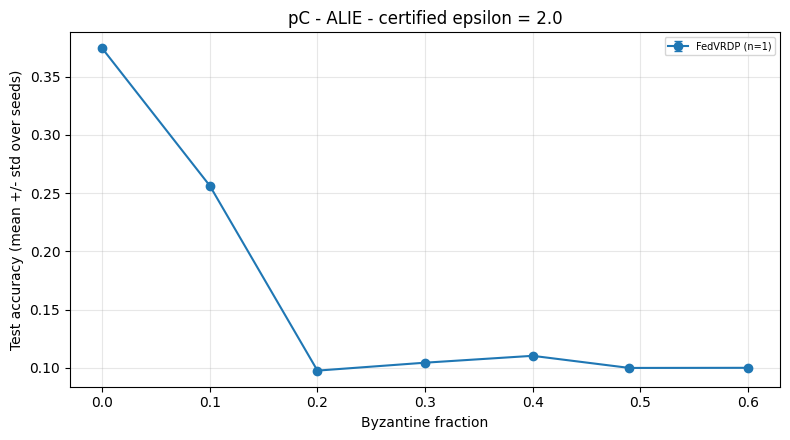

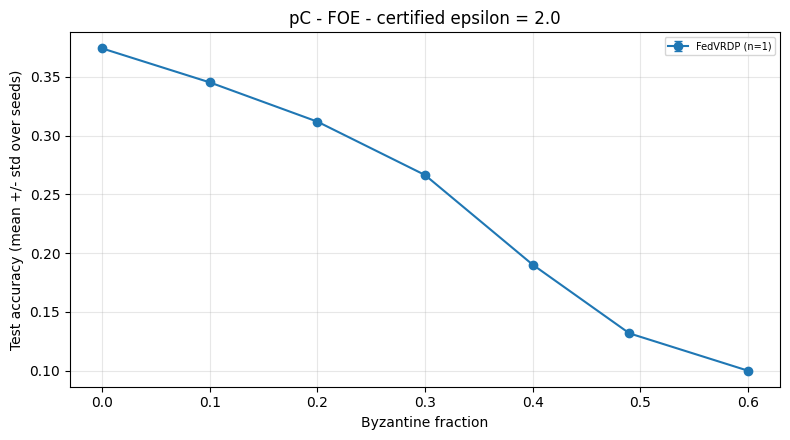

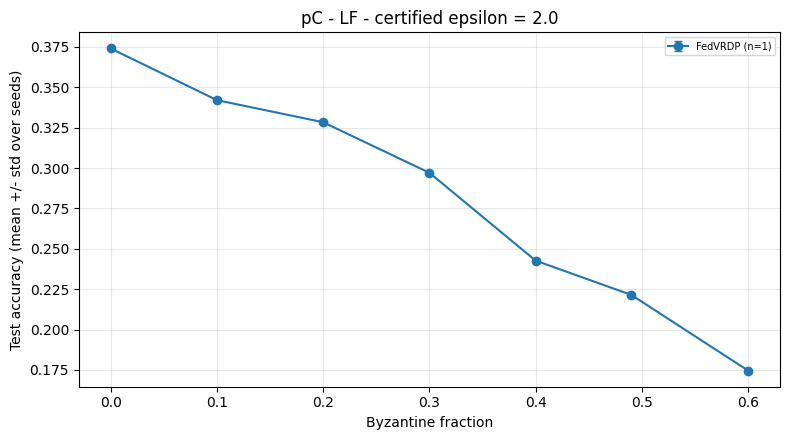

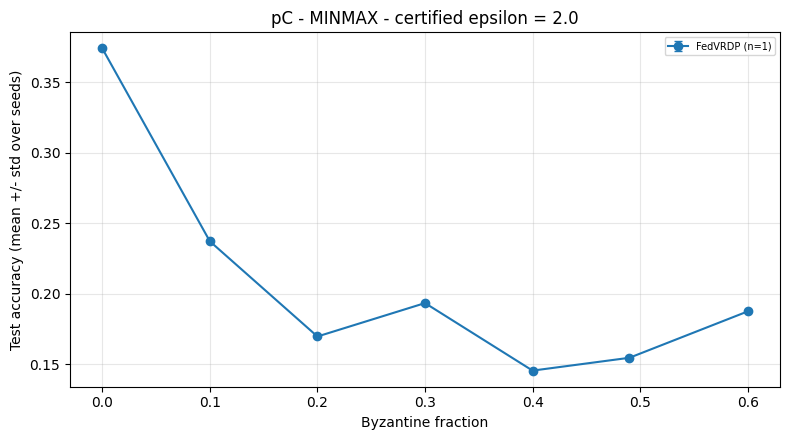

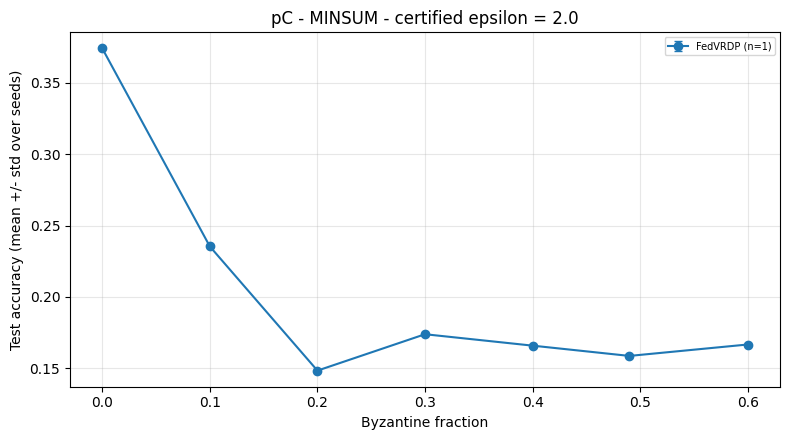

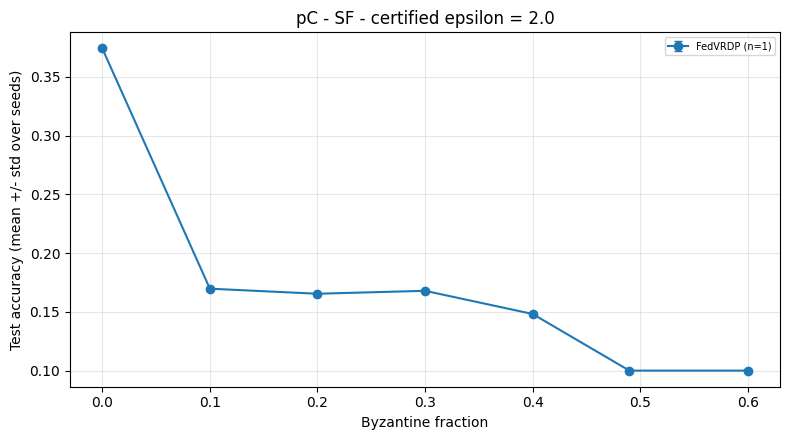

In [23]:
# Cell 16c — JOB "fedvrdp": 42 runs: faithful FedVRDP under the common protocol
run_job("fedvrdp")
import_legacy("fedvrdp")
print_job_log("fedvrdp")
aggregate("fedvrdp")
